# Лабораторна робота. Комп'ютерний практикум 1

---

## Задача 2, варіант 2 &nbsp;&nbsp; $g(y) = y^2 - 2y - 3$

---

## Аналітичне дослідження

Маємо автономне рівняння:
$$y' = g(y) = y^2 - 2y - 3 = (y - 3)(y + 1)$$

**Стаціонарні розв'язки** — нулі $g$:
$$y_1 = -1, \qquad y_2 = 3$$

### Пункт 1. Значення векторного поля

Для автономного рівняння нахил поля визначається лише значенням $y$. Обчислимо $g(y)$ у вузлових точках:

| $y$ | $g(y) = (y-3)(y+1)$ | Напрям |
|:---:|:---:|:---:|
| $-4$ | $(-7)(-3) = 21$ | $\nearrow$ |
| $-3$ | $(-6)(-2) = 12$ | $\nearrow$ |
| $-2$ | $(-5)(-1) = 5$ | $\nearrow$ |
| $-1$ | $0$ | $\rightarrow$ (стаціонарна) |
| $0$ | $(-3)(1) = -3$ | $\searrow$ |
| $1$ | $(-2)(2) = -4$ | $\searrow$ |
| $2$ | $(-1)(3) = -3$ | $\searrow$ |
| $3$ | $0$ | $\rightarrow$ (стаціонарна) |
| $4$ | $(1)(5) = 5$ | $\nearrow$ |

---

### Пункт 2. Зростання, спадання, перегин

**Знак $g(y)$** визначає монотонність:

$$g(y) > 0 \iff (y-3)(y+1) > 0 \iff y < -1 \text{ або } y > 3$$

Отже:
- **Зростання** інтегральних кривих: $y \in (-\infty,\,-1)\cup(3,\,+\infty)$
- **Спадання** інтегральних кривих: $y \in (-1,\,3)$

**Точки перегину.** Оскільки $y'' = g'(y)\cdot g(y)$, де $g'(y) = 2y - 2$:
$$y'' = 0 \iff g'(y) = 0 \;\text{ і }\; g(y) \neq 0 \iff y = 1$$
При $y < 1$: $g'(y) < 0$, $g(y) = -4 + \varepsilon < 0$, тому $y'' > 0$ (опуклість вниз $\cup$).
При $y > 1$ (але $y < 3$): $g'(y) > 0$, $g(y) < 0$, тому $y'' < 0$ (опуклість вгору $\cap$).

$$\boxed{\text{Пряма перегину: } y = 1}$$

---

### Пункт 3. Непродовжуваний розв'язок і вертикальні асимптоти

Розділяємо змінні ($y \neq -1,\, y \neq 3$):
$$\frac{dy}{(y-3)(y+1)} = dx$$

Розклад на прості дроби:
$$\frac{1}{(y-3)(y+1)} = \frac{1}{4}\cdot\frac{1}{y-3} - \frac{1}{4}\cdot\frac{1}{y+1}$$

Інтегруємо обидві частини:
$$\frac{1}{4}\Bigl(\ln|y-3| - \ln|y+1|\Bigr) = x + C
\implies \ln\left|\frac{y-3}{y+1}\right| = 4x + C_1$$

Звідси $\dfrac{y-3}{y+1} = A\,e^{4x}$. З умови $y(0)=y_0$ знаходимо $A = \dfrac{y_0-3}{y_0+1}$.

Розв'язуємо відносно $y$:
$$y - 3 = A e^{4x}(y+1) \implies y(1 - Ae^{4x}) = 3 + Ae^{4x}$$

$$\boxed{y(x,\,y_0) = \dfrac{3 + A\,e^{4x}}{1 - A\,e^{4x}},\qquad A = \dfrac{y_0 - 3}{y_0 + 1}}$$

**Вертикальна асимптота** — нуль знаменника $1 - Ae^{4x^*} = 0$:
$$x^* = -\frac{\ln A}{4} \quad \text{(існує лише при } A > 0\text{)}$$

| Діапазон $y_0$ | Знак $A$ | Асимптота $x^*$ | Інтервал $I_{y_0}$ |
|:---:|:---:|:---:|:---:|
| $y_0 < -1$ | $A > 1$ | $x^* < 0$ | $(x^*,\,+\infty)$ |
| $y_0 \in [-1,\,3]$ | $A \leq 0$ | немає | $(-\infty,\,+\infty)$ |
| $y_0 > 3$ | $0 < A < 1$ | $x^* > 0$ | $(-\infty,\,x^*)$ |

---

### Пункти 4–5. Графічний аналіз

Для **пункту 5** беремо межову точку $b = -1$ між зоною зростання та зоною спадання:
$$y_0^{+} = b + \tfrac{1}{2} = -\tfrac{1}{2} \in (-1,3), \qquad y_0^{-} = b - \tfrac{1}{2} = -\tfrac{3}{2} < -1$$

Відповідні константи:
$$A_1 = \frac{-1/2-3}{-1/2+1} = \frac{-7/2}{1/2} = -7 < 0 \implies \text{асимптоти немає}$$
$$A_2 = \frac{-3/2-3}{-3/2+1} = \frac{-9/2}{-1/2} = 9 > 1 \implies x^* = -\frac{\ln 9}{4} \approx -0.549$$

Обидві криві при $x \to +\infty$ прямують до стійкого рівноважного розв'язку $y \equiv -1$, тому їхня різниця спадає до нуля.

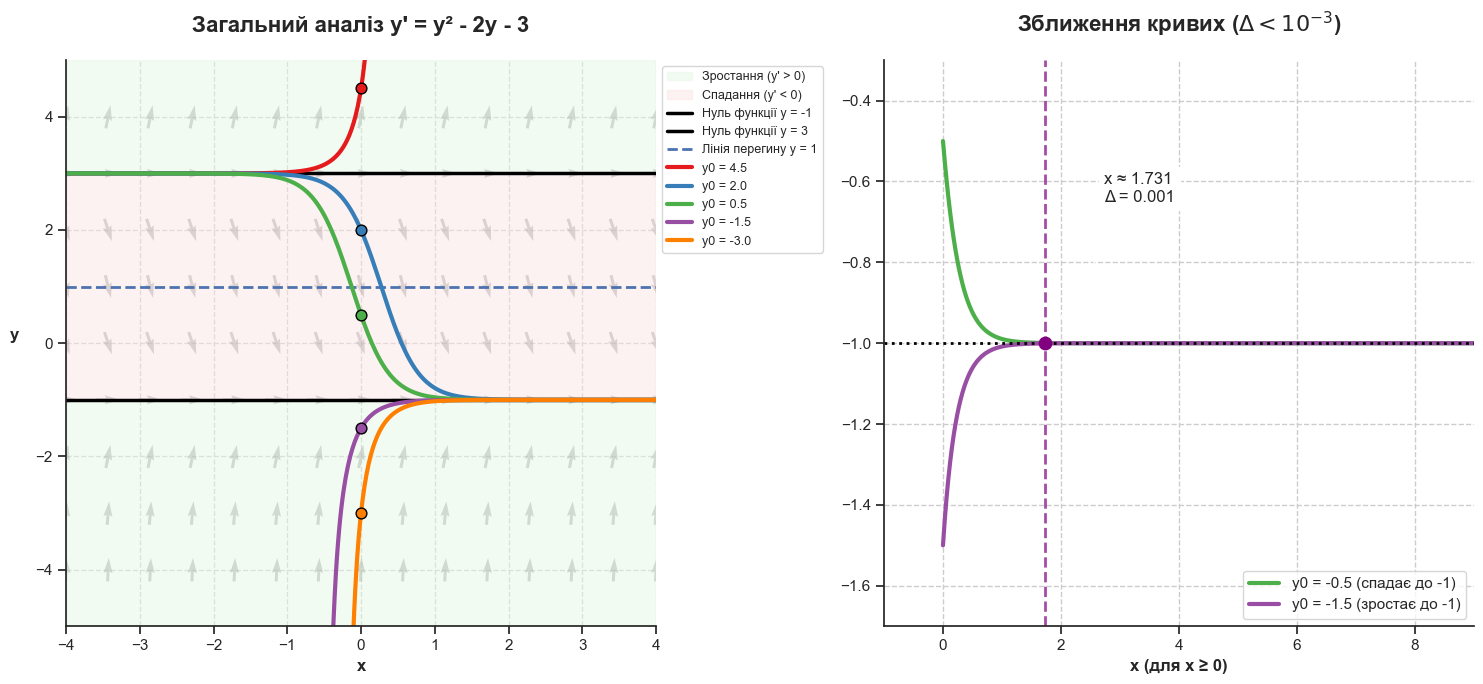

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import fsolve

sns.set_theme(style="whitegrid", context="notebook")
sns.set_style("ticks", {"axes.grid": True, "grid.linestyle": "--"})

# Явний розв'язок (пункт 3)
def exact_y(x, y0):
    if abs(y0 - (-1)) < 1e-9:
        return -1.0 * np.ones_like(np.asarray(x, dtype=float))
    if abs(y0 - 3) < 1e-9:
        return 3.0 * np.ones_like(np.asarray(x, dtype=float))
    K = (y0 - 3) / (y0 + 1)
    x = np.asarray(x, dtype=float)
    return (3 + K * np.exp(4 * x)) / (1 - K * np.exp(4 * x))

# Робимо 2 графіки: зліва - загальний аналіз, справа - задача з 5 пункту
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.set_xlim([-4, 4])
ax1.set_ylim([-5, 5])
ax1.set_xlabel('x', fontweight='bold')
ax1.set_ylabel('y', fontweight='bold', rotation=0, labelpad=15)
ax1.set_title("Загальний аналіз y' = y² - 2y - 3", fontsize=16, fontweight='bold', pad=20)

# Векторне поле для y = 0, +-1, +-2, +-3, +-4
x_pts = np.linspace(-4, 4, 15)
y_pts = np.arange(-4, 5, 1)
X, Y = np.meshgrid(x_pts, y_pts)
U = np.ones_like(X)
V = Y**2 - 2*Y - 3
norm = np.sqrt(U**2 + V**2)
ax1.quiver(X, Y, U/norm, V/norm, color='#7a7a7a', alpha=0.5, pivot='mid', scale=25)

# Області зростання та спадання
ax1.axhspan( 3,  5, color='#e6f9e6', alpha=0.5, label="Зростання (y' > 0)")
ax1.axhspan(-1,  3, color='#fde6e6', alpha=0.5, label="Спадання (y' < 0)")
ax1.axhspan(-5, -1, color='#e6f9e6', alpha=0.5)

# Лінії стаціонарних розв'язків та перегину
ax1.axhline(-1, color='black', lw=2.5, label='Нуль функції y = -1')
ax1.axhline( 3, color='black', lw=2.5, label='Нуль функції y = 3')
ax1.axhline( 1, color='#4c72b0', lw=2, ls='--', label='Лінія перегину y = 1')

# Малюємо криві за явною формулою для різних y0
y_starts = [4.5, 2.0, 0.5, -1.5, -3.0]
colors = sns.color_palette("Set1", len(y_starts))

for y0, col in zip(y_starts, colors):
    K = (y0 - 3) / (y0 + 1)
    if K > 0:
        x_asymp = -np.log(K) / 4
    else:
        x_asymp = None

    if y0 > 3:        # асимптота праворуч
        x_vals = np.linspace(-4, x_asymp - 0.04, 300)
    elif y0 < -1:     # асимптота ліворуч
        x_vals = np.linspace(x_asymp + 0.04, 4, 300)
    else:             # асимптот немає
        x_vals = np.linspace(-4, 4, 300)

    y_vals = exact_y(x_vals, y0)
    mask = (y_vals > -5.5) & (y_vals < 5.5)
    ax1.plot(x_vals[mask], y_vals[mask], color=col, lw=3, label=f'y0 = {y0}')
    ax1.scatter(0, y0, color=col, edgecolor='black', s=60, zorder=5)

ax1.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)

ax2.set_xlim([-1, 9])
ax2.set_ylim([-1.7, -0.3])
ax2.set_xlabel('x (для x ≥ 0)', fontweight='bold')
ax2.set_title(r"Зближення кривих ($\Delta < 10^{-3}$)", fontsize=16, fontweight='bold', pad=20)
x_zoom = np.linspace(0, 9, 300)
yA = exact_y(x_zoom, -0.5)
yB = exact_y(x_zoom, -1.5)

ax2.plot(x_zoom, yA, color=colors[2], lw=3, label='y0 = -0.5 (спадає до -1)')
ax2.plot(x_zoom, yB, color=colors[3], lw=3, label='y0 = -1.5 (зростає до -1)')
ax2.axhline(-1, color='black', lw=2, ls=':')

# Шукаємо точку, де різниця < 0.001
def diff(x):
    return abs(exact_y(x, -0.5) - exact_y(x, -1.5)) - 1e-3

# fsolve знаходить корінь рівняння. Шукаємо десь біля x=1.7
x_meet = fsolve(diff, 1.7)[0]

ax2.axvline(x_meet, color='purple', lw=2, ls='--', alpha=0.7)
ax2.scatter(x_meet, exact_y(x_meet, -0.5), color='purple', s=80, zorder=5)
ax2.annotate(f'x ≈ {x_meet:.3f}\nΔ = 0.001',
             xy=(x_meet, exact_y(x_meet, -0.5)),
             xytext=(x_meet + 1.0, -0.65),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=12, backgroundcolor='white')

ax2.legend(loc='lower right')

sns.despine(trim=False)
plt.tight_layout()
plt.savefig('Poshtak_lab_1_2.png', dpi=150, bbox_inches='tight')
plt.show()